In [1]:
import utils_inverse
import numpy as np
import pickle
import utils_plotting
%load_ext autoreload
%autoreload 2

# Evaluate emulator on zonal outputs from MESM

## 1. Generate initial parameters and create baseline emulator

In [ ]:
# Compute migrated to scripts/4c_evaluate_MESM_emulator.py (run
# standalone/scheduled; trains+evaluates the vector emulator on the baseline
# and CO2-only-optimized training sets, writes the pickles loaded below).
with open('data/plotting/baseline_co2_only_MESM.pkl', 'rb') as f:
    results_baseline = pickle.load(f)
with open('data/plotting/baseline_co2_only_MESM_diagnostics.pkl', 'rb') as f:
    diag_baseline = pickle.load(f)
preds_baseline, truths_baseline, lat_coords = diag_baseline['preds'], diag_baseline['truths'], diag_baseline['lat_coords']

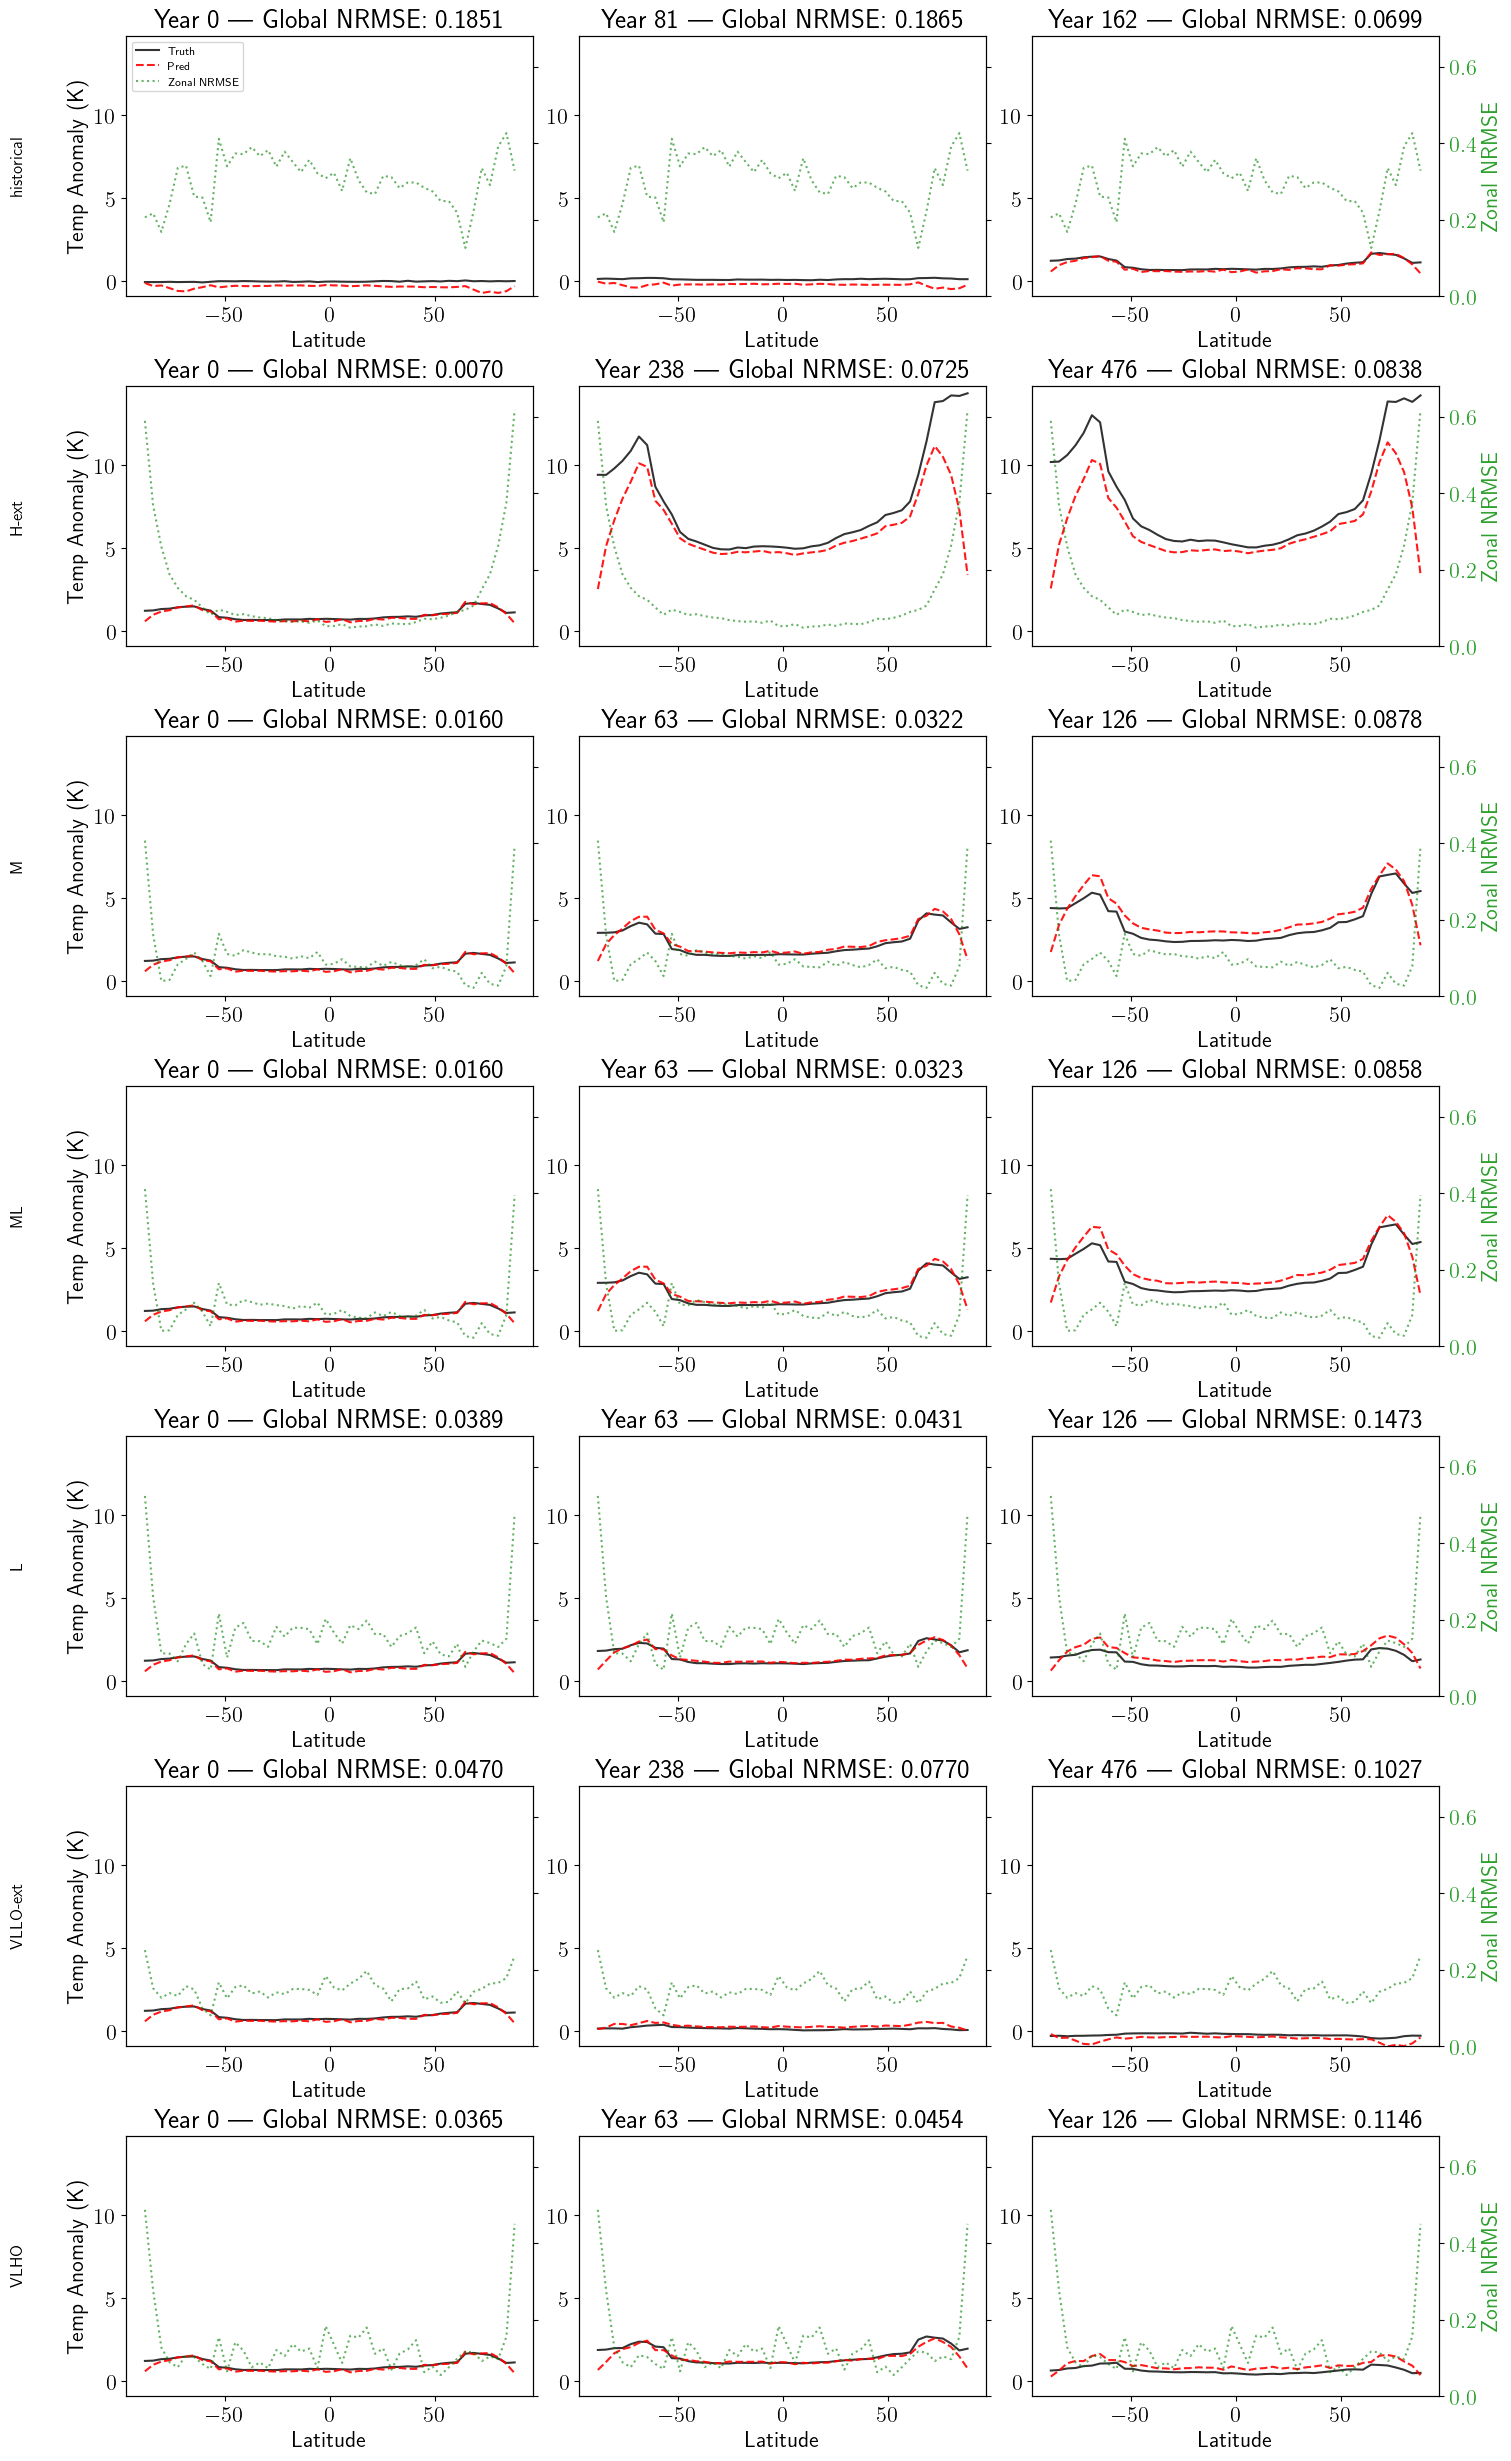

In [11]:
fig = utils_plotting.plot_zonal_predictions(results_baseline, preds_baseline, truths_baseline, lat_coords, eval_set='Tier 1')

## 2. Evaluate optimal emulators

In [ ]:
# Filename bug preserved as-is (flagged for Phase 5): this is the *combined*
# constant+sine optimized training result, but the original notebook's save
# cell leaked the last value of a for-loop variable into the filename, always
# "..._sine.pkl" regardless of scenario content - see scripts/
# 4c_evaluate_MESM_emulator.py's docstring for the full explanation.
with open('data/plotting/optimal_co2_only_MESM_sine.pkl', 'rb') as f:
    results_opt = pickle.load(f)
with open('data/plotting/optimal_co2_only_MESM_sine_diagnostics.pkl', 'rb') as f:
    diag_opt = pickle.load(f)
preds_opt, truths_opt = diag_opt['preds'], diag_opt['truths']

In [12]:
for key in results_baseline.keys():
  print('Eval set: ', key)
  for scen in results_baseline[key].keys():
    old = results_baseline[key][scen]['global']
    new = results_opt[key][scen]['global']
    pctChange = 100 * (old - new) / old
    print('\tScen:', scen, 'Change:', pctChange)
    print('\t\tRaw base:', old, 'Raw opt:', new)

Eval set:  Tier 1
	Scen: historical Change: -0.2490775745515058
		Raw base: 0.1624438613653183 Raw opt: 0.16284847259521484
	Scen: H-ext Change: 53.09378338246415
		Raw base: 0.06323207914829254 Raw opt: 0.029659776017069817
	Scen: M Change: 6.311125491442204
		Raw base: 0.04499489814043045 Raw opt: 0.04215521365404129
	Scen: ML Change: 4.271613833392128
		Raw base: 0.044806595891714096 Raw opt: 0.04289263114333153
	Scen: L Change: -33.30990471608022
		Raw base: 0.08011781424283981 Raw opt: 0.1068049818277359
	Scen: VLLO-ext Change: -63.15664819105803
		Raw base: 0.0772603452205658 Raw opt: 0.12605538964271545
	Scen: VLHO Change: -64.73026600701726
		Raw base: 0.06183202564716339 Raw opt: 0.1018560603260994
	Scen: mean Change: -12.361787644682135
		Raw base: 0.07564655706744927 Raw opt: 0.08499782381264064
Eval set:  Tier 2
	Scen: H-ext-OS Change: 51.93852730238528
		Raw base: 0.061009056866168976 Raw opt: 0.029321851208806038
	Scen: M-ext Change: 72.89844069119523
		Raw base: 0.128446

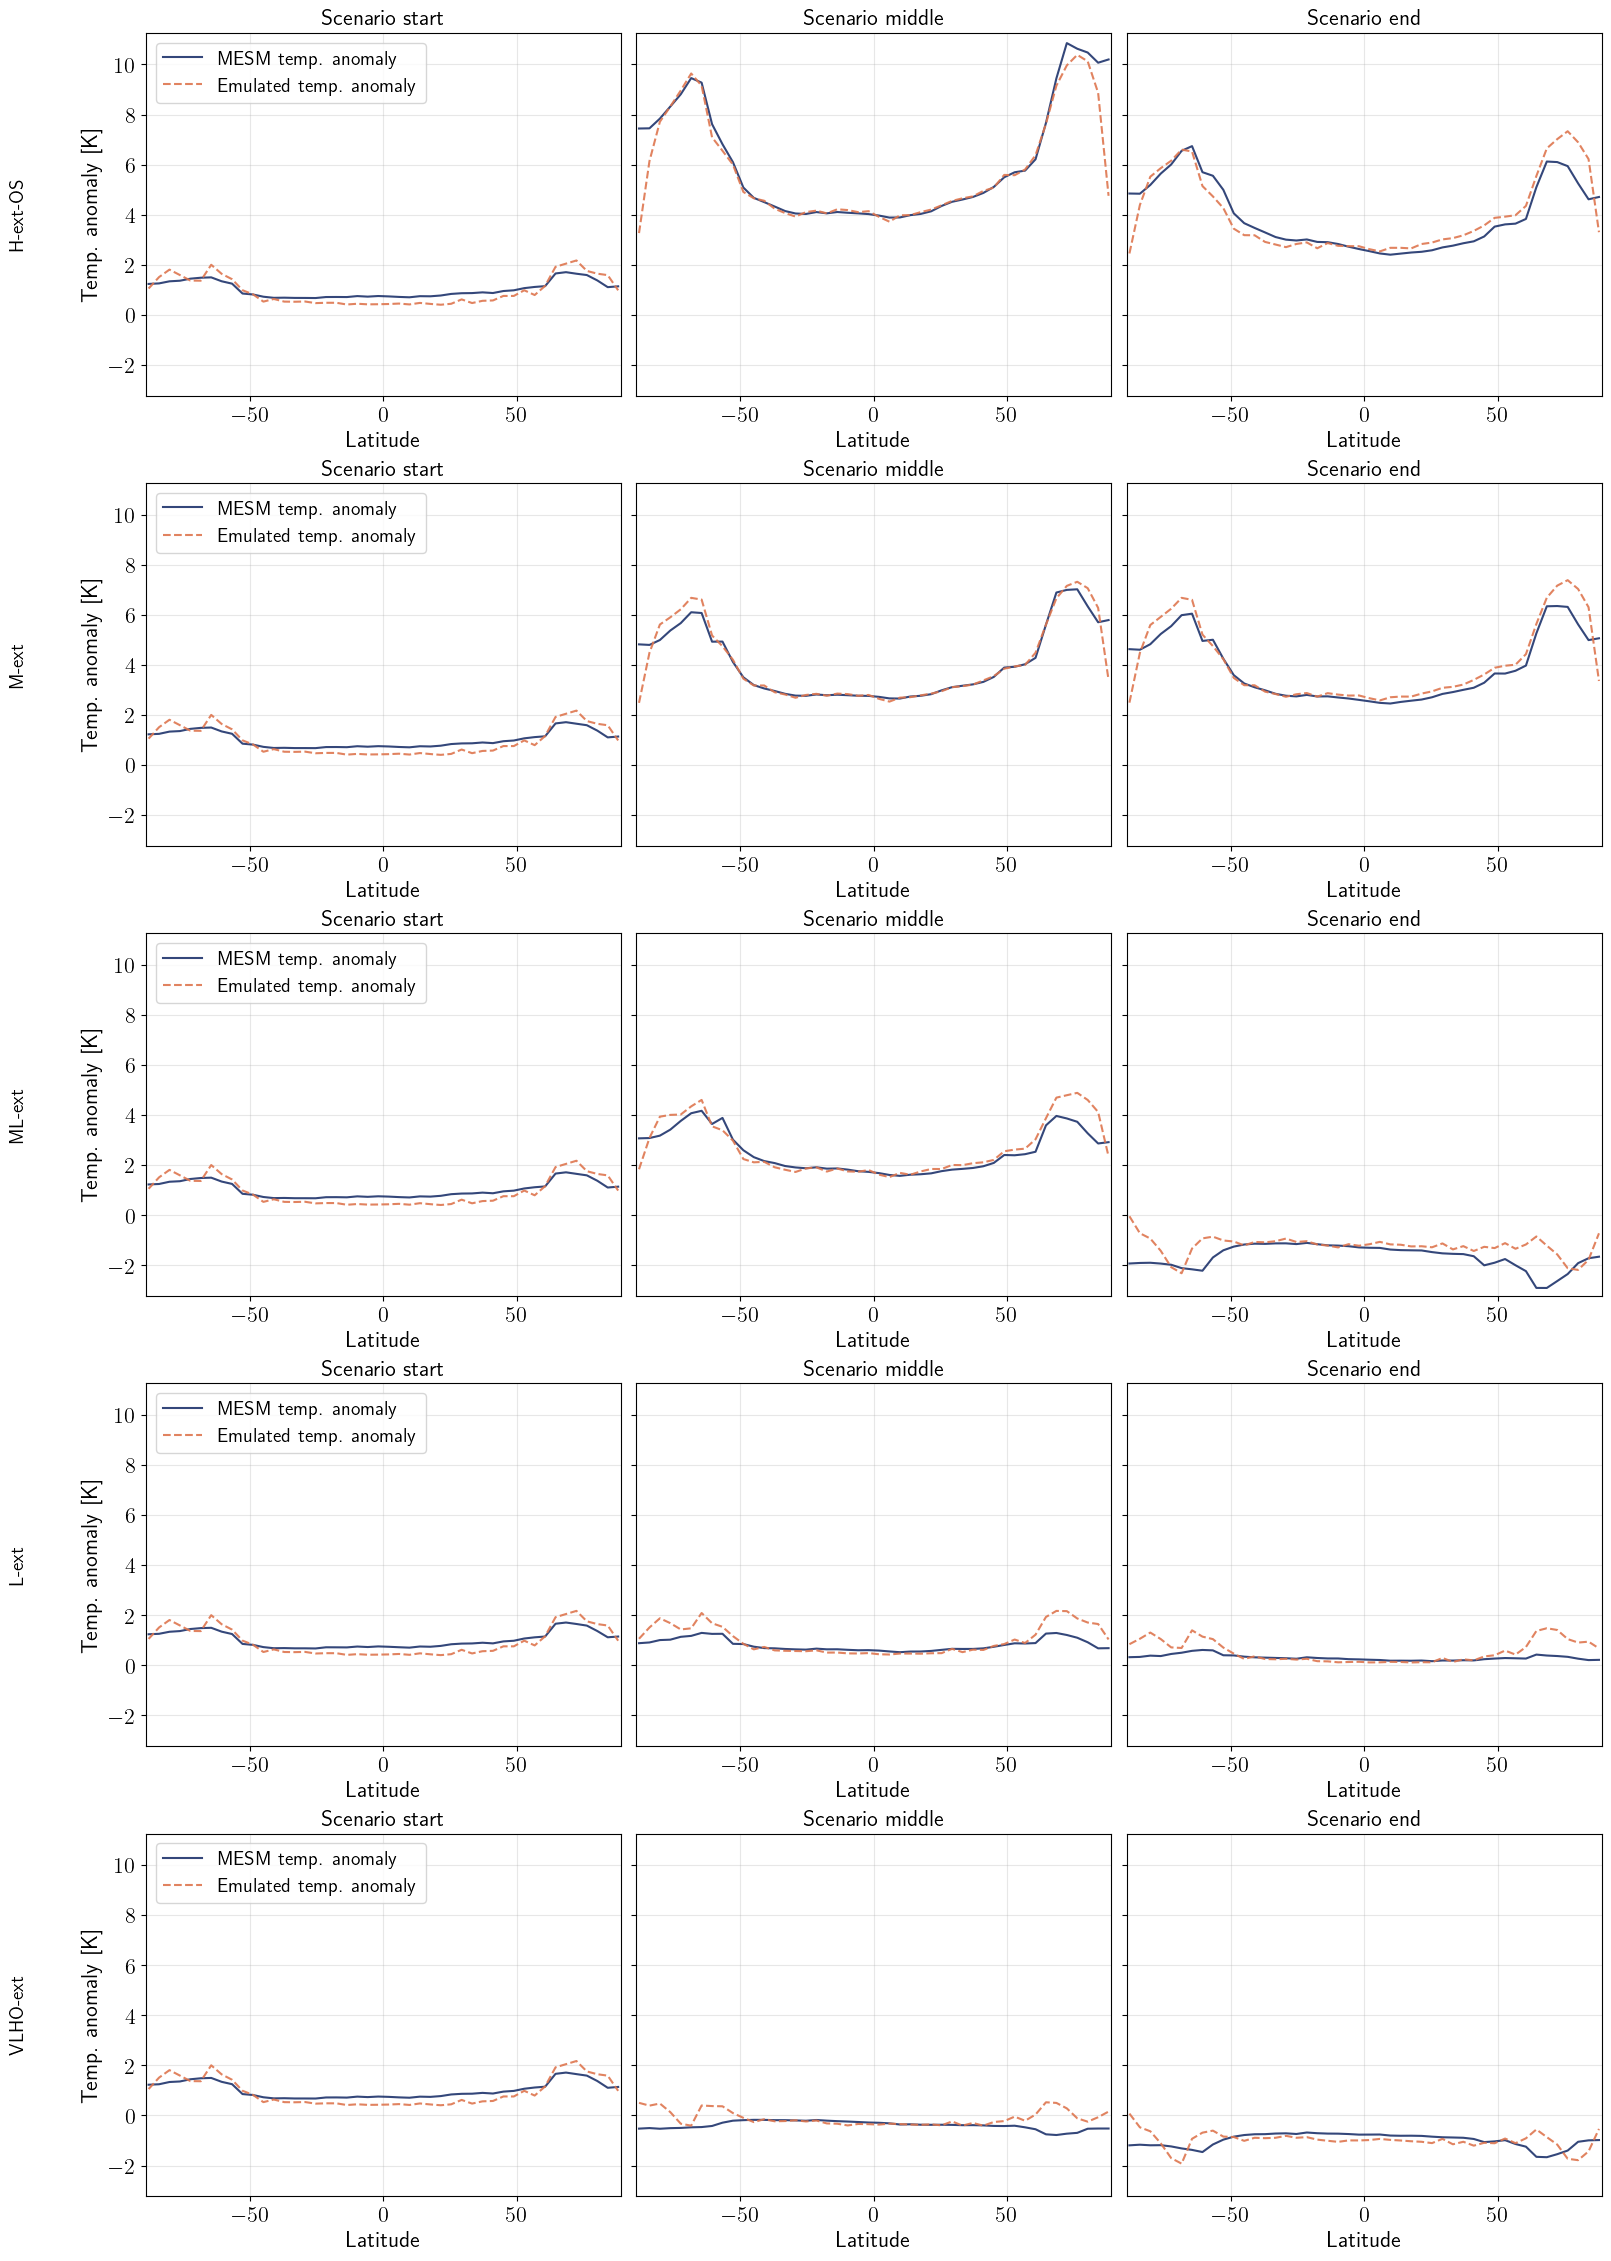

In [28]:
fig = utils_plotting.plot_zonal_predictions(results_opt, preds_opt, truths_opt, lat_coords, eval_set='Tier 2')